# Phase 1 — Dataset Inspection & Validation

Validates dataset structure, checks NIfTI files, computes label statistics, and creates train/val/test split.

**Kernel:** `gtx-1080-IP`

In [1]:
import sys, os
from pathlib import Path

# Set project root (one level up from notebooks/)
PROJECT_ROOT = Path(os.getcwd()).parent if 'notebooks' in os.getcwd() else Path(os.getcwd())
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')

Project root: k:\Coding\projects\integrative-project


In [2]:
from src.utils.config import load_config

# Change to 'full' for real training config
CONFIG = 'dev'
cfg = load_config(CONFIG)
print(f'Config: {CONFIG}')
print(f'Data root: {cfg["paths"]["data_root"]}')

Config: dev
Data root: K:\Coding\projects\integrative-project\data\raw


## Step 1 — Discover Samples

In [3]:
from src.data.dataset import discover_brats_samples

# Discover ALL samples (ignore max_samples for inspection)
samples = discover_brats_samples(cfg['paths']['data_root'], max_samples=None)
print(f'\nFirst sample:')
for k, v in samples[0].items():
    print(f'  {k}: {v}')

[Dataset] Found 30 valid samples in K:\Coding\projects\integrative-project\data\raw

First sample:
  patient_id: BraTS20_Training_001
  flair: K:\Coding\projects\integrative-project\data\raw\BraTS20_Training_001\BraTS20_Training_001_flair.nii
  t1ce: K:\Coding\projects\integrative-project\data\raw\BraTS20_Training_001\BraTS20_Training_001_t1ce.nii
  t1: K:\Coding\projects\integrative-project\data\raw\BraTS20_Training_001\BraTS20_Training_001_t1.nii
  t2: K:\Coding\projects\integrative-project\data\raw\BraTS20_Training_001\BraTS20_Training_001_t2.nii
  seg: K:\Coding\projects\integrative-project\data\raw\BraTS20_Training_001\BraTS20_Training_001_seg.nii


## Step 2 — Validate NIfTI Format

In [4]:
import nibabel as nib
import numpy as np

sample = samples[0]
print(f'Patient: {sample["patient_id"]}\n')

for modality in ['flair', 't1', 't1ce', 't2', 'seg']:
    nii = nib.load(sample[modality])
    print(f'  {modality:5s}: shape={nii.shape}, dtype={nii.get_data_dtype()}, spacing={np.array(nii.header.get_zooms()).round(3)}')

Patient: BraTS20_Training_001

  flair: shape=(240, 240, 155), dtype=int16, spacing=[1. 1. 1.]
  t1   : shape=(240, 240, 155), dtype=int16, spacing=[1. 1. 1.]
  t1ce : shape=(240, 240, 155), dtype=int16, spacing=[1. 1. 1.]
  t2   : shape=(240, 240, 155), dtype=int16, spacing=[1. 1. 1.]
  seg  : shape=(240, 240, 155), dtype=uint8, spacing=[1. 1. 1.]


## Step 3 — Volume & Spacing Statistics

In [5]:
from collections import Counter

shapes = []
spacings = []

for s in samples:
    nii = nib.load(s['flair'])
    shapes.append(nii.shape)
    spacings.append(nii.header.get_zooms())

shapes = np.array(shapes)
spacings = np.array(spacings)

print(f'Volumes: {len(samples)}')
print(f'Shape range: min={shapes.min(axis=0)}, max={shapes.max(axis=0)}')
print(f'Most common shape: {Counter(map(tuple, shapes)).most_common(1)[0]}')
print(f'Spacing range: min={spacings.min(axis=0).round(3)}, max={spacings.max(axis=0).round(3)}')

Volumes: 30
Shape range: min=[240 240 155], max=[240 240 155]
Most common shape: ((240, 240, 155), 30)
Spacing range: min=[1. 1. 1.], max=[1. 1. 1.]


## Step 4 — Label Analysis (Class Voxel Distribution)

In [6]:
total_voxels = Counter()
label_names = {0: 'Background', 1: 'NCR/NET', 2: 'Edema', 4: 'Enhancing'}

for s in samples:
    seg = nib.load(s['seg']).get_fdata()
    unique, counts = np.unique(seg.astype(int), return_counts=True)
    for u, c in zip(unique, counts):
        total_voxels[int(u)] += c

grand_total = sum(total_voxels.values())

print(f'Class voxel distribution across {len(samples)} volumes:\n')
for label in sorted(total_voxels.keys()):
    count = total_voxels[label]
    pct = 100.0 * count / grand_total
    name = label_names.get(label, f'Unknown({label})')
    print(f'  Label {label} ({name:12s}): {count:>15,} voxels ({pct:6.2f}%)')

Class voxel distribution across 30 volumes:

  Label 0 (Background  ):     265,388,255 voxels ( 99.08%)
  Label 1 (NCR/NET     ):         337,858 voxels (  0.13%)
  Label 2 (Edema       ):       1,723,976 voxels (  0.64%)
  Label 4 (Enhancing   ):         389,911 voxels (  0.15%)


## Step 5 — Create Train/Val/Test Split

In [7]:
from src.data.splits import create_splits

train_samples, val_samples, test_samples = create_splits(
    samples,
    ratios=cfg['data']['split_ratios'],
    seed=cfg['seed'],
    splits_dir=cfg['paths']['splits_dir'],
    force=False,  # Set True to recreate
)

print(f'\nTrain ({len(train_samples)}): {[s["patient_id"] for s in train_samples]}')
print(f'Val   ({len(val_samples)}):   {[s["patient_id"] for s in val_samples]}')
print(f'Test  ({len(test_samples)}):  {[s["patient_id"] for s in test_samples]}')

[Splits] Created split: train=21, val=4, test=5
[Splits] Saved to K:\Coding\projects\integrative-project\data\splits\split.json

Train (21): ['BraTS20_Training_001', 'BraTS20_Training_005', 'BraTS20_Training_017', 'BraTS20_Training_006', 'BraTS20_Training_014', 'BraTS20_Training_012', 'BraTS20_Training_023', 'BraTS20_Training_002', 'BraTS20_Training_003', 'BraTS20_Training_026', 'BraTS20_Training_004', 'BraTS20_Training_022', 'BraTS20_Training_027', 'BraTS20_Training_019', 'BraTS20_Training_030', 'BraTS20_Training_021', 'BraTS20_Training_008', 'BraTS20_Training_011', 'BraTS20_Training_015', 'BraTS20_Training_020', 'BraTS20_Training_007']
Val   (4):   ['BraTS20_Training_024', 'BraTS20_Training_009', 'BraTS20_Training_018', 'BraTS20_Training_029']
Test  (5):  ['BraTS20_Training_025', 'BraTS20_Training_016', 'BraTS20_Training_010', 'BraTS20_Training_028', 'BraTS20_Training_013']


## Step 6 — Visualize a Sample Slice

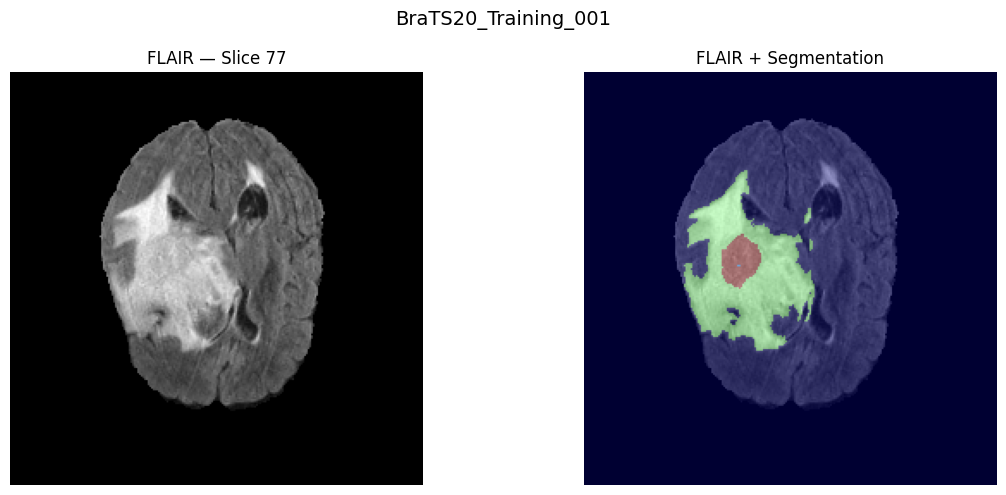


✅ Phase 1 complete.


In [8]:
import matplotlib.pyplot as plt

s = samples[0]
flair = nib.load(s['flair']).get_fdata()
seg = nib.load(s['seg']).get_fdata()

# Pick center axial slice
center = flair.shape[2] // 2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(flair[:, :, center].T, cmap='gray', origin='lower')
axes[0].set_title(f'FLAIR — Slice {center}')
axes[0].axis('off')

axes[1].imshow(flair[:, :, center].T, cmap='gray', origin='lower')
axes[1].imshow(seg[:, :, center].T, cmap='jet', alpha=0.4, origin='lower')
axes[1].set_title(f'FLAIR + Segmentation')
axes[1].axis('off')

plt.suptitle(s['patient_id'], fontsize=14)
plt.tight_layout()
plt.show()

print('\n✅ Phase 1 complete.')